In [31]:
# Bagging (배깅)
# 여러 개의 같은 종류의 모델을 만들어서 각각 학습시키고 결과를 평균하는 방법

# 주로 base model 로 결정트리를 많이 사용함
# 그 이유는 분산이 크고, 다양성이 좋음 
# KNN은 느리고 데이터가 많으면 부담이 큼, 로지스틱 회귀는 이미 안정적이기에 개선폭이 적음

In [32]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# 데이터
df = pd.DataFrame({
    "study":[1,2,3,4,5,6,7,8],
    "pass":[0,0,0,0,1,1,1,1]
})

x = df[["study"]]
y = df["pass"]

# 베이스 모델 = 기본 모델
tree = DecisionTreeClassifier()

# 배깅 적용
model = BaggingClassifier(
    estimator=tree,  # 기본 모델 설정
    n_estimators=5,  # 몇 개 모델을 만들 것인가
    random_state=42
)

# 학습
model.fit(x,y)

# 예측
pred = model.predict([[4.5]])
print(pred)

# 배깅은 주어진 데이터 안에서 sample을 랜덤으로 뽑아서 진행, 중복으로 들어가는 값이 있을 수도 있음
# n_estimators=5 모델을 5개 만든다고 하면 tree 5개를 만들어서 과반수로 합격,불합격 결정

# 장점
# 1. 예측률 증가
# 2. 과적합 해소 : 랜덤으로 샘플을 만들어서 진행을 하기 때문에 한가지를 중점으로 하는 거랑 다름

[0]


c:\miniconda3\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


In [33]:
# 통신사가 고객 해지 여부를 예측

# month   → 가입 개월 수
# fee     → 월 요금
# support → 고객센터 문의 횟수
# leave   → 해지 여부

# DecisionTree 사용
# BaggingClassifier 적용
# 트리 20개 생성
# 정확도 측정
# 신규 고객 예측

# 예측 대상

# 가입 10개월
# 월요금 45000원
# 문의 3회

# 이 고객은 해지할까?

In [38]:
import pandas as pd

# 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# 데이터 분할
from sklearn.model_selection import train_test_split

# 평가
from sklearn.metrics import accuracy_score


# -----------------------------
# 데이터 생성
# -----------------------------
df = pd.DataFrame({
    "month":[3,12,24,5,30,18,2,36],
    "fee":[30000,50000,70000,25000,80000,55000,20000,90000],
    "support":[1,5,8,1,10,6,0,12],
    "leave":[1,0,0,1,0,0,1,0]
})

x = df[["month","fee","support"]]
y = df["leave"]

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

tree = DecisionTreeClassifier(
    random_state=42
)

model = BaggingClassifier(
    estimator=tree,
    n_estimators=20,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)
print(pred)


print("정확도",accuracy_score(y_test,pred))


# 예측
result = model.predict([[10,45000,3]])
print(pred)

[1 0]
정확도 0.5
[1 0]


c:\miniconda3\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


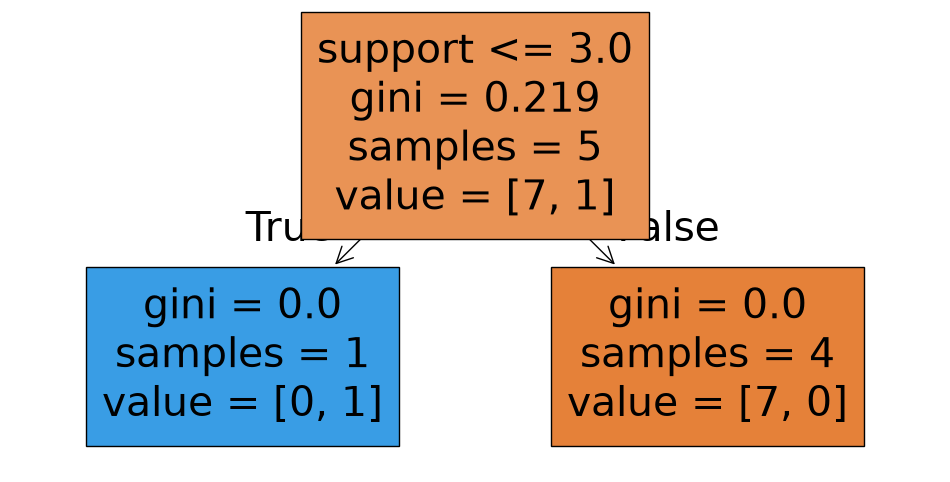

In [37]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plot_tree(
    model.estimators_[0],
    feature_names=x.columns,
    filled=True
)

plt.show()